<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Classification/Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing Dataset

In [19]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
X = df.iloc[:, 2:-1].values
y = df.iloc[:, -1].values

##Splitting Dataset into train and test set

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

##Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Training the Decision Tree Classification model on the training set

In [22]:
from sklearn.tree import DecisionTreeClassifier
cl = DecisionTreeClassifier(criterion='entropy', random_state = 0)
cl.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

##Predicting a new result

In [23]:
print(cl.predict(sc.transform([[30, 87000]])))

[0]


##Predicting test set results

In [24]:
y_pred = cl.predict(X_test)

y_pred_vector = y_pred.reshape(len(y_pred), 1)
y_test_vector = y_test.reshape(len(y_test), 1)

np.concatenate((y_test_vector, y_pred_vector), axis=1)

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 1],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0,

##Making Confusion Matrix

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[62  6]
 [ 3 29]]


Text(50.7222222222222, 0.5, 'Actual Values')

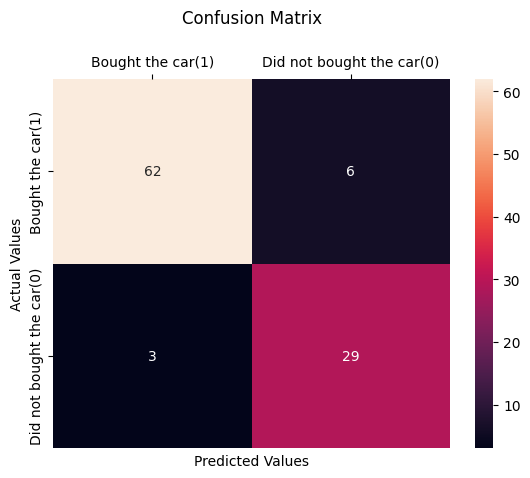

In [31]:
import seaborn as sns
sns.heatmap(cm, annot=True, xticklabels=['Bought the car(1)', 'Did not bought the car(0)'], yticklabels=['Bought the car(1)', 'Did not bought the car(0)'])
plt.tick_params(axis='x', labeltop=True, labelbottom=False, top=True, bottom=False)

plt.title("Confusion Matrix", pad=40)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.91

##Visualising the results

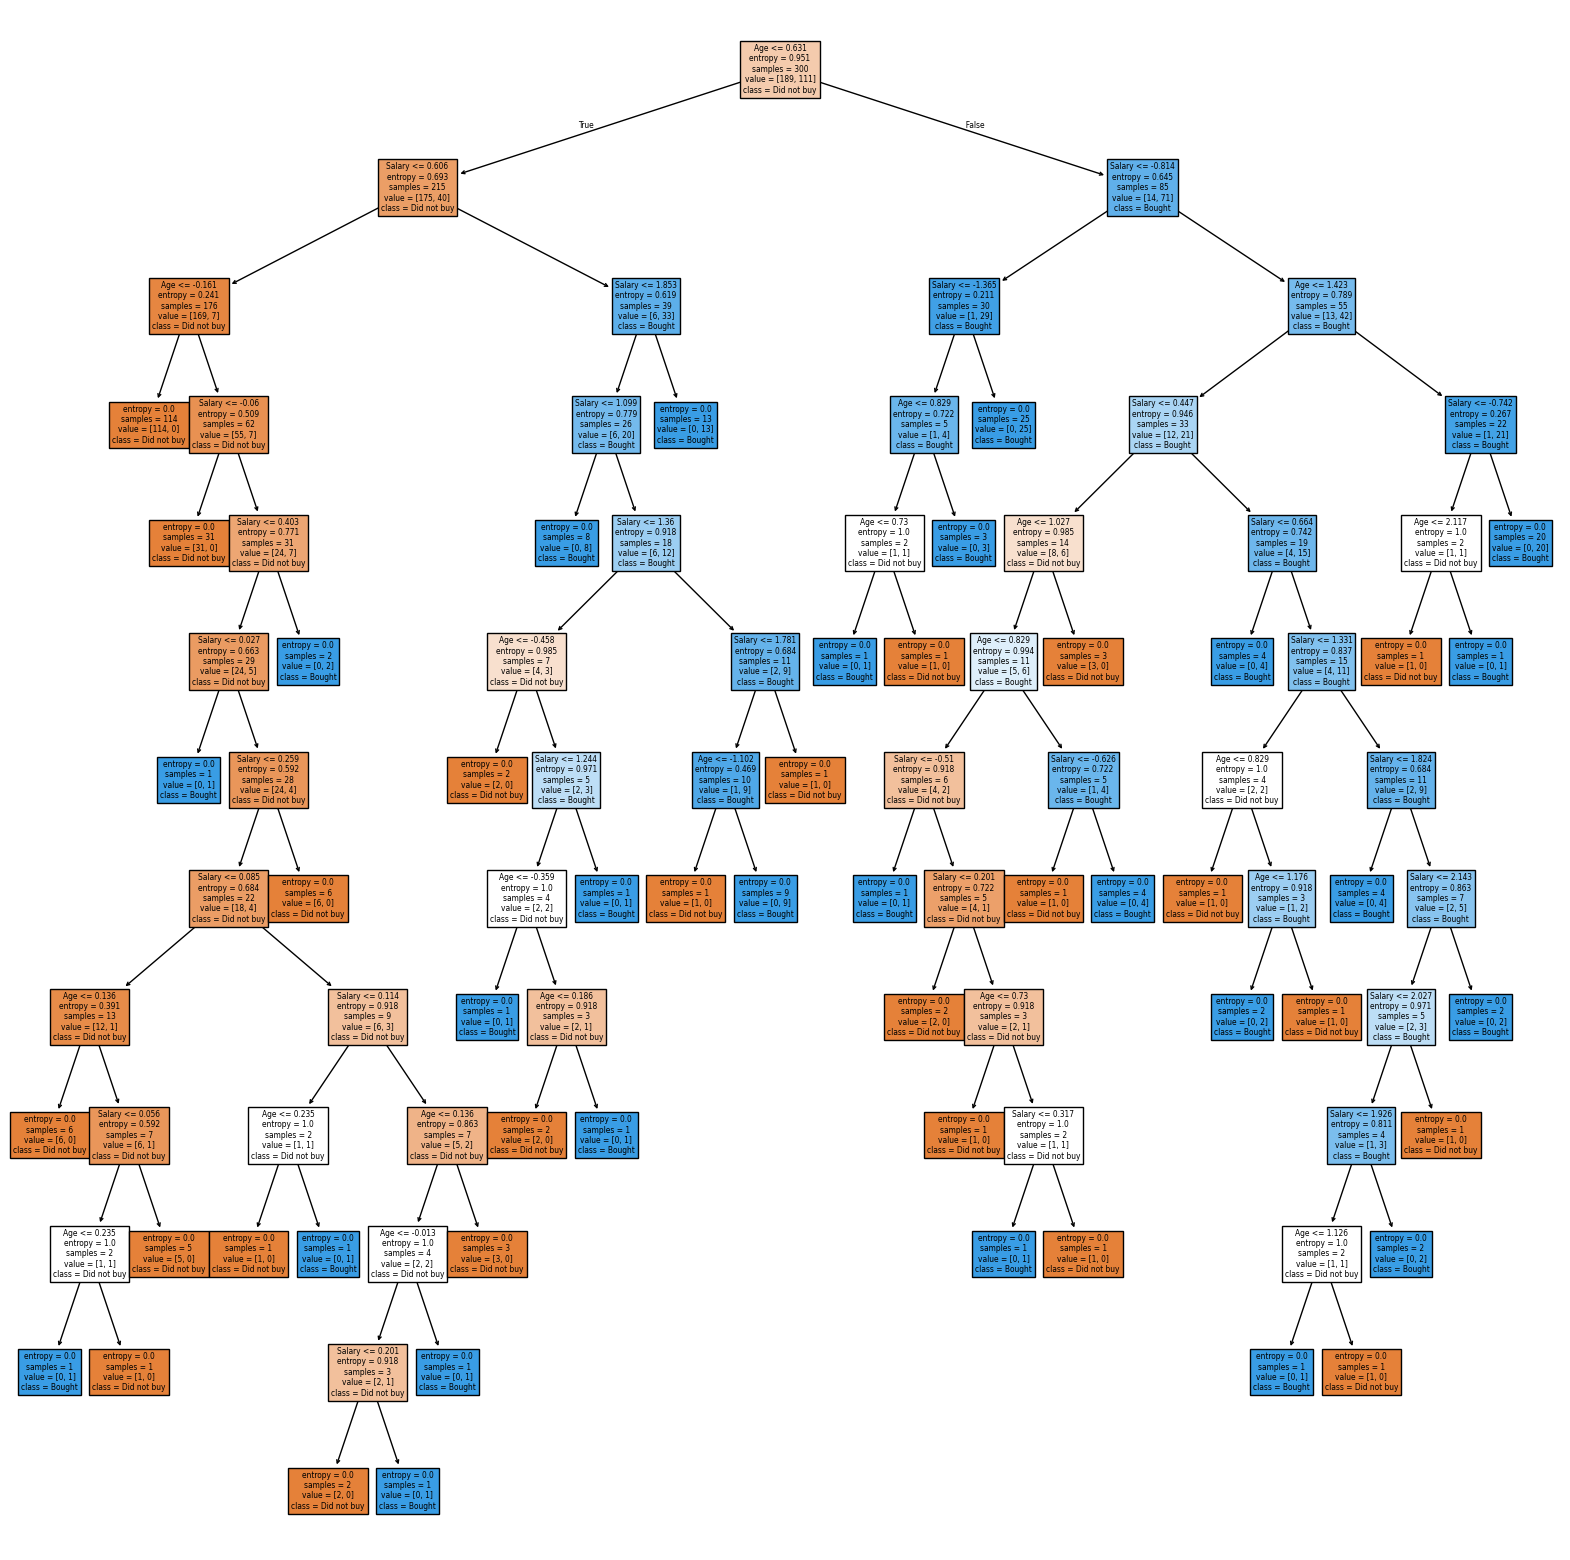

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,20))
plot_tree(cl,  # Classifier
          feature_names=['Age', 'Salary'],  # feature names form dataset
          class_names=['Did not buy', 'Bought'],  # class names
          filled=True,  # fill nodes with colors
          )
plt.show()